# Imports

In [1]:
import os
import boto3
import numpy as np
import pandas as pd
import tempfile
import xarray as xr
import keras

from huggingface_hub import hf_hub_download
from tornet.data.loader import read_file
from tornet.models.keras.layers import CoordConv2D

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

print("numpy:", np.__version__)

numpy: 2.4.2


# Access Data

In [2]:
# Setup S3
s3_client = boto3.client('s3')
bucket_name = 'ml-cloud-project-data'

# Download BOTH CSVs from S3
s3_client.download_file(bucket_name, 'choo_choo_data_3.csv', 'choo_choo_data_3.csv')
s3_client.download_file(bucket_name, 'choo_choo_data_final.csv', 'choo_choo_data_final.csv')

# Load both datasets
df_old = pd.read_csv('choo_choo_data_3.csv')
df_new = pd.read_csv('choo_choo_data_final.csv')

print("Old dataset rows:", len(df_old))
print("New dataset rows:", len(df_new))

# ---------- Merge datasets ----------
df = pd.concat([df_old, df_new], ignore_index=True)

print("Rows after merge:", len(df))

duplicates = df.duplicated(subset=['filepath','frame_idx']).sum()
print("Duplicate radar frames found:", duplicates)

# ---------- Remove duplicates ----------
# A radar frame should be uniquely defined by filepath + frame_idx
df = df.drop_duplicates(subset=['filepath', 'frame_idx'])

print("Rows after removing duplicates:", len(df))

# ---------- Standardize labels ----------
label_map = {
    'hook': 'tornado_hook',
    'tornado_hook': 'tornado_hook',
    'no_hook': 'tornado_no_hook',
    'tornado_no_hook': 'tornado_no_hook',
    'non_tornadic': 'non_tornadic'
}

df['label'] = df['label'].map(label_map)

print("\nLabel counts after merging equivalent labels:")
print(df['label'].value_counts())

print(f"\nLoaded {len(df)} rows total")
print(df.head(2))

Old dataset rows: 756
New dataset rows: 2147
Rows after merge: 2903
Duplicate radar frames found: 756
Rows after removing duplicates: 2147

Label counts after merging equivalent labels:
label
tornado_no_hook    1523
non_tornadic        396
tornado_hook        228
Name: count, dtype: int64

Loaded 2147 rows total
                                            filepath  \
0  s3://ml-cloud-project-data/tornet_2018/train/2...   
1  s3://ml-cloud-project-data/tornet_2018/train/2...   

                             event_id  frame_idx         label  
0  WRN_180503_081318_KDYX_1080276n_T7          0  non_tornadic  
1  WRN_180503_081318_KDYX_1080276n_T7          1  non_tornadic  


In [ ]:
# Load pretrained model
model_file = hf_hub_download(
    repo_id="tornet-ml/tornado_detector_baseline_v1",
    filename="tornado_detector_baseline.keras"
)

cnn = keras.models.load_model(
    model_file,
    compile=False,
    custom_objects={"CoordConv2D": CoordConv2D}
)

print("Model inputs:", list(cnn.input.keys()))

# Run inference
variables = ['DBZ', 'VEL']
results = []

def build_model_inputs(data, frame_idx):

    dbz = data["DBZ"][frame_idx]
    vel = data["VEL"][frame_idx]

    zeros = np.zeros_like(dbz, dtype=np.float32)

    return {
        "DBZ": dbz[np.newaxis],
        "VEL": vel[np.newaxis],
        "KDP": zeros[np.newaxis],
        "RHOHV": zeros[np.newaxis],
        "ZDR": zeros[np.newaxis],
        "WIDTH": zeros[np.newaxis],
        "range_folded_mask": zeros[np.newaxis]
    }
    

for k, v in cnn.input.items():
    print(k, v.shape)


# ---------- OPTIMIZED INFERENCE ----------
# Group rows by radar file so each file is downloaded once
for filepath, group in df.groupby("filepath"):

    s3_key = filepath.replace(f's3://{bucket_name}/', '')

    try:

        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:

            # Download radar file ONCE
            s3_client.download_file(bucket_name, s3_key, tmp.name)

            # Load radar frames once
            data = read_file(tmp.name, variables=variables, n_frames=4)

            # Open dataset once for coordinates
            ds = xr.open_dataset(tmp.name)
            az = ds['azimuth'].values
            rng = ds['range'].values

            az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')

            az_norm = az_grid / 360.0
            rng_norm = rng_grid / 150000.0

            coords_template = np.stack([az_norm, rng_norm], axis=-1)
            ds.close()

            # Process each frame belonging to this radar file
            for _, row in group.iterrows():

                frame_idx = row["frame_idx"]

                coords = coords_template[np.newaxis].astype(np.float32)

                xin = build_model_inputs(data, frame_idx)
                xin["coordinates"] = coords

                logit = cnn.predict(xin, verbose=0)
                prob = float(1 / (1 + np.exp(-logit[0, 0])))

                results.append({
                    'filepath': row['filepath'],
                    'event_id': row['event_id'],
                    'frame_idx': frame_idx,
                    'label': row['label'],
                    'tornado_prob': prob
                })

                print(f"✓ {row['event_id']} frame {frame_idx} → prob={prob:.3f}")

    except Exception as e:

        print(f"✗ Failed file {filepath}: {e}")
        continue


results_df = pd.DataFrame(results)
results_df.to_csv('pretrained_inference_results.csv', index=False)

# Upload results back to S3
s3_client.upload_file(
    'pretrained_inference_results.csv',
    bucket_name,
    'pretrained_inference_results.csv'
)

print(f"\nDone. {len(results_df)}/{len(df)} succeeded.")

Model inputs: ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates']
DBZ (None, None, None, 2)
VEL (None, None, None, 2)
KDP (None, None, None, 2)
RHOHV (None, None, None, 2)
ZDR (None, None, None, 2)
WIDTH (None, None, None, 2)
range_folded_mask (None, None, None, 2)
coordinates (None, None, None, 2)
✓ TOR_130918_194410_KABX_469691_F3 frame 0 → prob=0.084
✓ TOR_130918_194410_KABX_469691_F3 frame 1 → prob=0.009
✓ TOR_130918_194410_KABX_469691_F3 frame 2 → prob=0.009
✓ TOR_130918_194410_KABX_469691_F3 frame 3 → prob=0.034
✓ TOR_131031_150019_KLCH_480339_W9 frame 0 → prob=0.008
✓ TOR_131031_150019_KLCH_480339_W9 frame 1 → prob=0.010
✓ TOR_131031_150019_KLCH_480339_W9 frame 2 → prob=0.009
✓ TOR_131031_150019_KLCH_480339_W9 frame 3 → prob=0.011
✓ TOR_131031_235523_KPAH_477076_T8 frame 0 → prob=0.018
✓ TOR_131031_235523_KPAH_477076_T8 frame 1 → prob=0.050
✓ TOR_131031_235523_KPAH_477076_T8 frame 2 → prob=0.019
✓ TOR_131031_235523_KPAH_477076_T8 frame 3 → prob=0.0

In [14]:
print("DBZ shape:", data["DBZ"].shape)  # should be (n_frames, H, W, 2)
print("VEL shape:", data["VEL"].shape)

DBZ shape: (4, 120, 240, 2)
VEL shape: (4, 120, 240, 2)


In [4]:
# ---------- Step 1: Keep only tornado cases ----------
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
print(len(tornado_df))

tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    'tornado_hook': 1
})
print("Class counts:", tornado_df['binary_label'].value_counts())

1751
Class counts: binary_label
0    1523
1     228
Name: count, dtype: int64


# Model with Data Augmentation

In [5]:
def make_coordinates(filepath, frame_idx):
    """
    Create normalized coordinate channels for radar data.
    Returns a dictionary with 'azimuth' and 'range' 2D grids.
    """
    ds = xr.open_dataset(filepath)  # open NetCDF file
    az = ds['azimuth'].values       # 1D array of azimuth angles
    rng = ds['range'].values        # 1D array of range gates

    # Create 2D grids for azimuth and range
    az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')  # shape (az_len, rng_len)

    # Normalize between 0 and 1
    az_norm = az_grid / 360.0
    rng_norm = rng_grid / np.max(rng)

    # Expand dims to match CNN input (H, W, 1)
    az_norm = az_norm[..., np.newaxis]
    rng_norm = rng_norm[..., np.newaxis]

    # Stack together if you want single "coordinates" input channel
    coords = np.concatenate([az_norm, rng_norm], axis=-1)  # shape (H, W, 2)

    # If your model expects a batch dimension:
    coords = np.expand_dims(coords, axis=0)  # shape (1, H, W, 2)

    return coords

# ---------- Step 1: Keep only tornado cases ----------
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    'tornado_hook': 1
})
print("Class counts:", tornado_df['binary_label'].value_counts())

# ---------- Step 2: Load data from S3 ----------
X_data = []
y_data = []
meta_data = []

for _, row in tornado_df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']

    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)
            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)

        xin = build_model_inputs(data, frame_idx)
        xin['coordinates'] = coords

        X_data.append({k: xin[k][0] for k in xin})
        y_data.append(row['binary_label'])

        # store metadata
        meta_data.append({
            "filepath": row['filepath'],
            "frame_idx": row['frame_idx'],
            "original_label": row['label']
        })

    except Exception as e:
        print("Failed:", e)
        continue

# Stack inputs for model
X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
y_data = np.array(y_data)
meta_df = pd.DataFrame(meta_data)

# ---------- Step 3: Split train/val ----------
indices = np.arange(len(y_data))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

X_train = {k: v[train_idx] for k, v in X_stacked.items()}
X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
y_train = y_data[train_idx]
y_val   = y_data[val_idx]
meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
meta_val = meta_df.iloc[val_idx].reset_index(drop=True)

# ---------- Step 5: Data augmentation ----------
def augment_batch(batch_dict):
    """Apply safe augmentations for TorNet radar inputs."""
    batch_aug = {}
    for k, x in batch_dict.items():
        # x.shape = (batch, H, W, C)
        x_aug = x.copy()
        # Random horizontal flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=2)  # flip width
        # Random vertical flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=1)  # flip height
        # Add small Gaussian noise
        noise = np.random.normal(scale=0.01, size=x_aug.shape)
        x_aug = x_aug + noise
        # Clip to valid radar range if needed
        batch_aug[k] = x_aug.astype(np.float32)
    return batch_aug

def generator(X_dict, y, class_weight_dict=None):

    hook_idx = np.where(y == 1)[0]
    nonhook_idx = np.where(y == 0)[0]

    batch_size = 8
    half_batch = batch_size // 2

    while True:

        hook_batch = np.random.choice(hook_idx, half_batch)
        nonhook_batch = np.random.choice(nonhook_idx, half_batch)

        batch_idx = np.concatenate([hook_batch, nonhook_batch])
        np.random.shuffle(batch_idx)

        X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
        X_batch = augment_batch(X_batch)

        y_batch = y[batch_idx]

        yield (X_batch, y_batch)

train_gen = generator(X_train, y_train)
val_gen = generator(X_val, y_val)

steps_per_epoch = len(y_train) // 8
validation_steps = len(y_val) // 8

# ---------- Step 6: Compile and train ----------
feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
for layer in feature_extractor.layers[:-15]:
    layer.trainable = False
for layer in feature_extractor.layers[-15:]:
    layer.trainable = True

x = feature_extractor.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(inputs=feature_extractor.input, outputs=output)
model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

from sklearn.metrics import roc_auc_score
y_score = model.predict(X_val, batch_size=8)[:,1]
auc = roc_auc_score(y_val, y_score)
print("Validation AUC:", auc)

Class counts: binary_label
0    1523
1     228
Name: count, dtype: int64
Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 668ms/step - accuracy: 0.4771 - loss: 0.8945 - val_accuracy: 0.5465 - val_loss: 0.7161
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 107s 611ms/step - accuracy: 0.4886 - loss: 0.8653 - val_accuracy: 0.5727 - val_loss: 0.7100
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 626ms/step - accuracy: 0.5143 - loss: 0.8413 - val_accuracy: 0.5000 - val_loss: 0.7007
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 116s 662ms/step - accuracy: 0.4921 - loss: 0.8416 - val_accuracy: 0.5203 - val_loss: 0.6986
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 116s 662ms/step - accuracy: 0.4836 - loss: 0.8590 - val_accuracy: 0.4855 - val_loss: 0.6993
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 112s 642ms/step - accuracy: 0.4814 - loss: 0.8062 - val_accuracy: 0.5000 - val_loss: 0.7003
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 111s 637ms/step - accuracy: 0.4800 - loss: 0.7008 - val_accuracy: 0.5000 - val_loss: 0.7001
Epo

In [6]:
for i, layer in enumerate(feature_extractor.layers):
    print(i, layer.name, layer.trainable)

0 DBZ False
1 VEL False
2 KDP False
3 RHOHV False
4 ZDR False
5 WIDTH False
6 Normalize_DBZ False
7 Normalize_VEL False
8 Normalize_KDP False
9 Normalize_RHOHV False
10 Normalize_ZDR False
11 Normalize_WIDTH False
12 Concatenate1 False
13 range_folded_mask False
14 Concatenate2 False
15 coordinates False
16 coord_conv2d_20 False
17 coord_conv2d_21 False
18 max_pooling2d_16 False
19 dropout_8 False
20 max_pooling2d_17 False
21 coord_conv2d_22 False
22 coord_conv2d_23 False
23 max_pooling2d_18 False
24 dropout_9 False
25 max_pooling2d_19 True
26 coord_conv2d_24 True
27 coord_conv2d_25 True
28 coord_conv2d_26 True
29 max_pooling2d_20 True
30 dropout_10 True
31 max_pooling2d_21 True
32 coord_conv2d_27 True
33 coord_conv2d_28 True
34 coord_conv2d_29 True
35 max_pooling2d_22 True
36 dropout_11 True
37 conv2d_32 True
38 conv2d_33 True
39 heatmap True


In [7]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DBZ (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VEL (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ KDP (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RHOHV (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ZDR (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ WIDTH (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_DBZ       │ (None, None,      │          0 │ DBZ[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_VEL       │ (None, None,      │          0 │ VEL[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_KDP       │ (None, None,      │          0 │ KDP[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_RHOHV     │ (None, None,      │          0 │ RHOHV[0][0]       │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_ZDR       │ (None, None,      │          0 │ ZDR[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_WIDTH     │ (None, None,      │          0 │ WIDTH[0][0]       │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate1        │ (None, None,      │          0 │ Normalize_DBZ[0]… │
│ (Concatenate)       │ None, 12)         │            │ Normalize_VEL[0]… │
│                     │                   │            │ Normalize_KDP[0]… │
│                     │                   │            │ Normalize_RHOHV[… │
│                     │                   │            │ Normalize_ZDR[0]… │
│                     │                   │            │ Normalize_WIDTH[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ isnan_4 (Isnan)     │ (None, None,      │          0 │ Concatenate1[0][… │
│                     │ None, 12)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ where_4 (Where)     │ (None, None,      │          0 │ isnan_4[0][0],    │
│                     │ None, 12)         │            │ Concatenate1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,685,451 (52.21 MB)

 Trainable params: 4,509,507 (17.20 MB)

 Non-trainable params: 156,928 (613.00 KB)

 Optimizer params: 9,019,016 (34.40 MB)

# Plots

## Loss

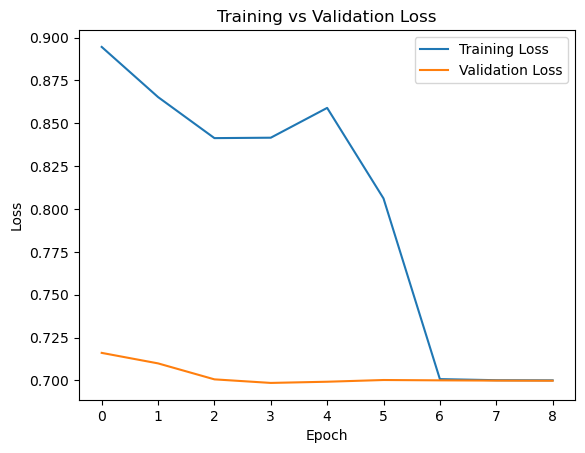

9

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


len(history.history['loss'])

## ROC

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 931ms/step


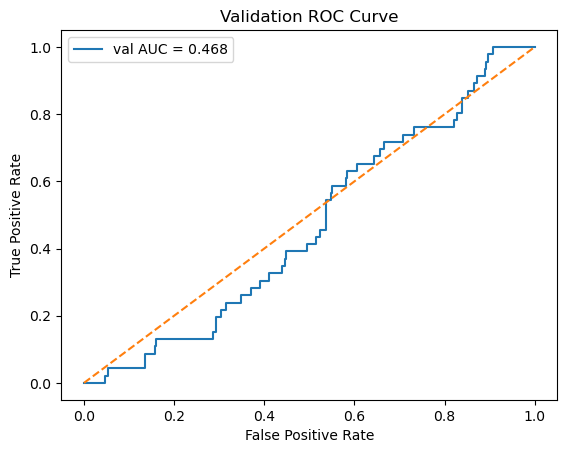

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val)[:, 1] # this is for softmax
# y_pred_prob = model.predict(X_val).ravel() # use this for sigmoid

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"val AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

## Confusion

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 987ms/step


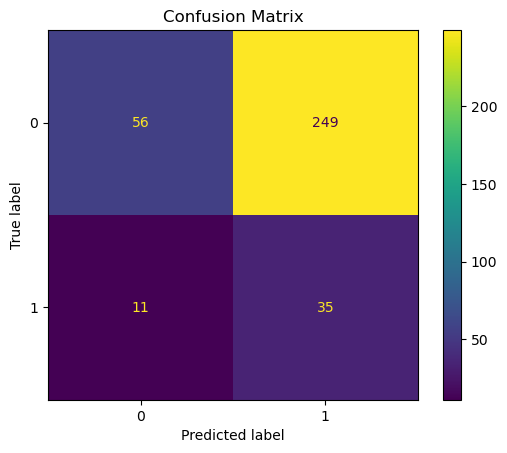

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1) # this is for softmax
# y_pred_prob = model.predict(X_val).ravel() # for sigmmoid 
# y_pred = (y_pred_prob >= 0.5).astype(int) # for sigmoid

cm = confusion_matrix(y_val, y_pred)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

# Metrics

In [11]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_val)  # convert generator output if needed
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred_classes, target_names=['non-hook', 'hook']))

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 986ms/step
              precision    recall  f1-score   support

    non-hook       0.84      0.18      0.30       305
        hook       0.12      0.76      0.21        46

    accuracy                           0.26       351
   macro avg       0.48      0.47      0.26       351
weighted avg       0.74      0.26      0.29       351



In [12]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_score = model.predict(X_val, batch_size=8)[:,1]

precision, recall, thresholds = precision_recall_curve(y_val, y_score)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 253ms/step
Best threshold: 0.49543852
Precision: 0.14241486068111456
Recall: 1.0
F1: 0.24932249104251586


# Save to .csv

In [13]:
# Saving predictions and create csv file
y_prob = model.predict(X_val, batch_size=8)
y_pred = np.argmax(y_prob, axis=1)
y_score = y_prob[:,1]
y_prob_all = model.predict(X_stacked, batch_size=8)

results_df = meta_val.copy()

results_df["true_label"] = y_val
results_df["predicted_label"] = y_pred
results_df["hook_probability"] = y_score

results_df["predicted_class"] = results_df["predicted_label"].map({
    0: "tornado_no_hook",
    1: "tornado_hook"
})

results_df.to_csv("tornet_validation_predictions.csv", index=False)

44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 267ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 262ms/step
